
# Probing what drives TETHER's predictions

The goal here is to see *how* the two stacked models turn their inputs into a score, by
holding a fixed set of real TF-TG edges and changing one input at a time.

**What each model sees**

| Model | Inputs | Output |
|---|---|---|
| `TFPeakBindingModel` (TF-DNA, frozen) | TF 3Di protein embedding, peak one-hot DNA `[L, 4]` | one binding logit per (TF, peak) |
| `TFTGRegulationModel` (TF-TG) | per-peak: binding prob, accessibility, `dist_scaled`, `dist_weight`; per-cell: TF expr, TG expr | one logit per (TF, TG) edge |

Inside `TFTGRegulationModel.forward` the peak features are built as

```
binding_score   = sigmoid(frozen_tf_dna_model(tf, peak_seq))       # [E, P]  masked by peak_mask
distance_scaled = clamp(|TSS_dist| / 250_000, 0, 1)                # [E, P]
distance_weight = exp(-|TSS_dist| / 50_000)                        # [E, P]
peak_features   = stack([binding, accessibility, dist_scaled, dist_weight])   # [E, C, P, 4]
```

1. A TG query built from `tf_expr + tg_expr` attends over the P peak tokens.
2. The classifier emits one logit per (edge, cell)
3. Those are pooled over the C sampled cells with
log-sum-exp into one edge logit.

**Two consequences worth keeping in mind while reading the sweeps below:**

1. The TF-DNA model *only* sees the TF embedding and the peak DNA sequence. Changing
   accessibility, distance, or expression cannot change a binding score — those sweeps
   move the TF-TG head only.
2. `peak_mask` is the switch that controls how many peaks an edge has. Masked peaks get
   binding, distance, and accessibility zeroed *and* are excluded from the attention
   (`key_padding_mask`), so flipping the mask is the faithful way to ask "what if this TG
   had fewer nearby peaks?".

**Run this on a GPU node** (`sbatch jupyter_dense_a100.sh`, kernel `my_env`).


## Setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import seaborn as sns
from Bio import SeqIO

import config
import utils
import stat_utils
import plotting_utils
import models.tf_to_tg_testing as tf_to_tg_module

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CELL_TYPE = "mESC"
SAMPLE_NAME = "E7.5_rep1"
SPECIES = "mouse"
SPECIES_BUILD = config.species_for_cell_type(CELL_TYPE) # mm10 or hg38

training_cache_dir = PROJECT_DIR / "cached_data" / SPECIES_BUILD / f"{CELL_TYPE}_tf_tg_cache"

print(f"{SPECIES} / {CELL_TYPE} / {SAMPLE_NAME} on {device}")

mouse / mESC / E7.5_rep1 on cuda



## 1. Load the cached test edges

`utils.load_training_cache_dataset` gives back a `DataLoader` over the cached test split
plus the TF embedding lookup tables. Nothing is rebuilt from the raw multiome data — these
are the exact edges the model was evaluated on.

Each collated batch is a dict of:

| key | shape | meaning |
|---|---|---|
| `label` | `[E]` | 1 = ground-truth edge |
| `tf_embedding` | `[E, T, 128]` | TF 3Di embedding, padded to the longest protein |
| `tf_mask` | `[E, T]` | True = amino acid sequence, False = padding |
| `peak_sequences` | `[E, P, L, 4]` | one-hot DNA for each candidate peak |
| `peak_distance` | `[E, P]` | signed peak-to-TSS distance (bp) |
| `peak_mask` | `[E, P]` | True = real peak, False = padding |
| `peak_accessibility` | `[E, C, P]` | ATAC signal per sampled cell |
| `tf_expression` / `tg_expression` | `[E, C]` | TF/TG RNA expression per sampled cell |
| `cell_mask` | `[E, C]` | True = real cell |

Peaks are stored **sorted by increasing `|TSS_dist|`**, so column `p` is the p-th closest
peak to the TG. That ordering is used to select the k nearest peaks to a TG TSS.

In [2]:
# Enough edges to find a decent number of positives; the cache is TF-major, so a
# small subset can be all one TF. Raise SCAN_EDGES if you want more variety.
SCAN_EDGES = 4096
BATCH_SIZE = 64

loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
    sample_name=SAMPLE_NAME,
    cell_type_cache_dir=training_cache_dir,
    split_type="test",
    subset_size=SCAN_EDGES,
    batch_size=BATCH_SIZE,
)

print("max_peaks_real   :", metadata["max_peaks_real"])
print("max_cells_per_pair:", metadata["max_cells_per_pair"])
print("n test edges     :", manifest["n_test_rows"])
print("tf_embeddings    :", tuple(tf_embeddings_tensor.shape))
print()
example = next(iter(loader))
for key, value in example.items():
    if torch.is_tensor(value):
        print(f"{key:20s} {str(tuple(value.shape)):20s} {value.dtype}")

max_peaks_real   : 25
max_cells_per_pair: 64
n test edges     : 72543
tf_embeddings    : (443, 5588, 128)

label                (64,)                torch.float32
tf_idx               (64,)                torch.int64
tg_idx               (64,)                torch.int64
peak_indices         (64, 25)             torch.int64
peak_sequences       (64, 25, 256, 4)     torch.float32
peak_distance        (64, 25)             torch.float32
peak_mask            (64, 25)             torch.bool
peak_accessibility   (64, 64, 25)         torch.float32
tf_expression        (64, 64)             torch.float32
tg_expression        (64, 64)             torch.float32
tf_embedding         (64, 5588, 128)      torch.float32
tf_mask              (64, 5588)           torch.bool
cell_mask            (64, 64)             torch.bool



## 2. Load the models

`utils.load_tf_tg_regulation_model` rebuilds both models and loads both checkpoints: it
loads the TF-DNA checkpoint, freezes that model, and hands it to `TFTGRegulationModel` as
the `tf_peak_model` submodule. So the frozen TF-DNA model used for the binding sweeps is
literally the same object the TF-TG model calls internally — no risk of probing different
weights than the ones making the predictions.

In [5]:
TF_DNA_CKPT = config.tf_dna_model_checkpoints[CELL_TYPE]
TF_TG_CKPT = utils.find_latest_checkpoint(config.CHKPT_DIR, CELL_TYPE, SAMPLE_NAME)

print("TF-DNA checkpoint:", TF_DNA_CKPT.name)
print("TF-TG  checkpoint:", TF_TG_CKPT.name)

tf_tg_lit = utils.load_tf_tg_regulation_model(
    tf_dna_model_path=TF_DNA_CKPT,
    tf_tg_model_path=TF_TG_CKPT,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    tf_peak_chunk_size=128,
    compile_model=False,   # keep off: the sweeps change shapes and compile would re-trace
    device=device,
    model_module=tf_to_tg_module
)
tf_tg_lit = tf_tg_lit.to(device).eval()

tf_tg_model = tf_tg_lit.model                  # TFTGRegulationModel
tf_dna_model = tf_tg_model.tf_peak_model       # the frozen TFPeakBindingModel inside it

print("pooling:", tf_tg_lit.pooling_mode, "temperature:", tf_tg_lit.pooling_temperature)

INFO:root:Latest checkpoint for mESC E7.5_rep1: Job 3858927 Epoch 17


TF-DNA checkpoint: mm10_3831017_epoch_12.ckpt
TF-TG  checkpoint: epoch=17-macro=0.6504-val_auroc=0.7386-val_loss=0.8036.ckpt


INFO:root:Detected compiled TF-TG checkpoint. Stripping _orig_mod prefixes.


pooling: lse temperature: 1.0



## 3. Prediction helpers

Three things to make the rest of the notebook short:

* `predict_edges` — full TF-TG forward on a batch, returning edge and per-cell scores.
  It calls `LitTFTGRegulationModel.forward`, i.e. exactly the path used in training/eval.
* `tf_dna_binding` — runs the frozen TF-DNA model alone on every (TF, peak) pair in a
  batch, so you can see the binding layer that feeds the head.
* `clone_batch` / `subset_batch` / `concat_batches` — for building perturbed copies.

In [ ]:
@torch.no_grad()
def predict_edges(batch):
    """Full TF-TG forward. Returns edge probs [E], edge logits [E], cell logits [E, C]."""
    device_batch = tf_to_tg_module.move_batch_to_device(batch, device)
    edge_logits, cell_logits = tf_tg_lit(device_batch)
    return (
        torch.sigmoid(edge_logits).float().cpu(),
        edge_logits.float().cpu(),
        cell_logits.float().cpu(),
    )


@torch.no_grad()
def tf_dna_binding(batch, chunk_size=256):
    """Frozen TF-DNA model on every (TF, peak) pair. Returns binding probs [E, P].

    This is the `binding_score` tensor the TF-TG head consumes, before masking. Only the
    TF embedding and the peak DNA sequence enter here -- accessibility, distance, and
    expression are invisible to this model.
    """
    E, P = batch["peak_mask"].shape
    L = batch["peak_sequences"].shape[2]

    peak_seq_flat = batch["peak_sequences"].reshape(E * P, L, 4).float()
    tf_rows = batch["tf_idx"].repeat_interleave(P)          # [E*P] rows of the TF table

    out = torch.zeros(E * P)
    for start in range(0, E * P, chunk_size):
        sel = slice(start, min(start + chunk_size, E * P))
        rows = tf_rows[sel]

        tf_emb = tf_embeddings_tensor[rows].float()
        tf_msk = tf_mask_tensor[rows].bool()

        # Crop trailing all-padding positions
        crop = int(tf_msk.sum(dim=1).max())
        tf_emb, tf_msk = tf_emb[:, :crop], tf_msk[:, :crop]

        logits = tf_dna_model(
            tf_embedding=tf_emb.to(device),
            tf_mask=tf_msk.to(device),
            peak_embedding=peak_seq_flat[sel].to(device),
        )
        out[sel] = torch.sigmoid(logits).float().cpu()

    return out.reshape(E, P)


def clone_batch(batch):
    return {k: (v.clone() if torch.is_tensor(v) else list(v)) for k, v in batch.items()}


def subset_batch(batch, idx):
    idx = torch.as_tensor(idx, dtype=torch.long)
    out = {}
    for key, value in batch.items():
        if torch.is_tensor(value):
            out[key] = value[idx]
        else:
            out[key] = [value[i] for i in idx.tolist()]
    return out


# Peak axis -> which dim holds it, for every key collate_tftg_edge_bags gives a peak
# axis. Needed by pad_peak_axis below: it does not vary within a single loader batch,
# but PEAK_CROP_LADDER (see collate_tftg_edge_bags) trims each loader batch to a
# different rung depending on that batch's own longest real peak count, so two
# sub-batches pulled from different loader batches can disagree on P.
PEAK_AXIS = {
    "peak_indices": 1,
    "peak_sequences": 1,
    "peak_distance": 1,
    "peak_mask": 1,
    "peak_accessibility": 2,   # [E, C, P] -- peak axis is last here, not dim 1
}


def pad_peak_axis(batch, target_P):
    """Right-pad every peak-axis tensor in `batch` out to target_P columns.

    Safe padding, not just convenient: every padded column is False in peak_mask, and
    TFTGRegulationModel.forward masks every other peak-axis feature by peak_mask before
    it is used (see section 2b/3/4 there), so a padded column can never reach the model
    as if it were real.
    """
    P = batch["peak_mask"].shape[1]
    if P == target_P:
        return batch

    out = dict(batch)
    for key, axis in PEAK_AXIS.items():
        if key not in out:
            continue
        value = out[key]
        pad_shape = list(value.shape)
        pad_shape[axis] = target_P - P
        filler = torch.zeros(pad_shape, dtype=value.dtype)
        out[key] = torch.cat([value, filler], dim=axis)
    return out


def concat_batches(batches):
    target_P = max(b["peak_mask"].shape[1] for b in batches)
    batches = [pad_peak_axis(b, target_P) for b in batches]

    out = {}
    for key, value in batches[0].items():
        if torch.is_tensor(value):
            out[key] = torch.cat([b[key] for b in batches], dim=0)
        else:
            out[key] = [x for b in batches for x in b[key]]
    return out


def collect_edges(loader, n_pos, n_neg, max_batches=64):
    """Pull edges off the loader until n_pos positives and n_neg negatives are collected."""
    pos, neg = [], []
    n_have_pos = n_have_neg = 0

    for i, batch in enumerate(loader):
        if i >= max_batches or (n_have_pos >= n_pos and n_have_neg >= n_neg):
            break
        labels = batch["label"]
        if n_have_pos < n_pos:
            take = torch.nonzero(labels == 1).ravel()[: n_pos - n_have_pos]
            if len(take):
                pos.append(subset_batch(batch, take))
                n_have_pos += len(take)
        if n_have_neg < n_neg:
            take = torch.nonzero(labels == 0).ravel()[: n_neg - n_have_neg]
            if len(take):
                neg.append(subset_batch(batch, take))
                n_have_neg += len(take)

    print(f"collected {n_have_pos} positives / {n_have_neg} negatives")
    return concat_batches(pos + neg)


## 4. Baseline: unmodified test edges

Before perturbing anything, look at what the model does on the real data and how its score
tracks the five factors *as they naturally co-vary*. This is observational — a factor can
look predictive here purely because it correlates with something else (e.g. TGs with many
nearby peaks also tend to be highly expressed). The sweeps in §5 are the controlled version
of the same question.

In [ ]:
input = next(iter(loader))
for key, value in input.items():
    if torch.is_tensor(value):
        print(f"{key:20s} {str(tuple(value.shape)):20s} {value.dtype}")
        

label                (64,)                torch.float32
tf_idx               (64,)                torch.int64
tg_idx               (64,)                torch.int64
peak_indices         (64, 25)             torch.int64
peak_sequences       (64, 25, 256, 4)     torch.float32
peak_distance        (64, 25)             torch.float32
peak_mask            (64, 25)             torch.bool
peak_accessibility   (64, 64, 25)         torch.float32
tf_expression        (64, 64)             torch.float32
tg_expression        (64, 64)             torch.float32
tf_embedding         (64, 5588, 128)      torch.float32
tf_mask              (64, 5588)           torch.bool
cell_mask            (64, 64)             torch.bool


In [67]:
print(str(input["label"][0].float().cpu()))

tensor(1.)


In [60]:
device_batch = tf_to_tg_module.move_batch_to_device(input, device)
outputs = tf_tg_lit(device_batch)

prediction = torch.sigmoid(outputs[0]).float().cpu(),
tf_tg_logit = outputs[0].float().cpu(),
per_cell_logits = outputs[1].float().cpu(),

print("prediction shape:", prediction[0].shape)
print("tf_tg_logit shape:", tf_tg_logit[0].shape)
print("per_cell_logits shape:", per_cell_logits[0].shape)

prediction shape: torch.Size([64])
tf_tg_logit shape: torch.Size([64])
per_cell_logits shape: torch.Size([64, 64])


In [71]:
peak_attn_chunks = []

def _force_weights(module, args, kwargs):
    kwargs = dict(kwargs)
    kwargs["need_weights"] = True
    kwargs["average_attn_weights"] = False  # keep per-head weights; set True to average
    return args, kwargs

def _capture_weights(module, inputs, output):
    _, attn_weights = output  # [rows_in_chunk, num_heads, 1, P]
    peak_attn_chunks.append(attn_weights.detach().float().cpu())
    
def attention_rollout(attentions):
    # Initialize rollout with identity matrix
    rollout = torch.eye(attentions[0].size(-1)).to(attentions[0].device)

    # Multiply attention maps layer by layer
    for attention in attentions:
        attention_heads_fused = attention.mean(dim=1) # Average attention across heads
        attention_heads_fused += torch.eye(attention_heads_fused.size(-1)).to(attention_heads_fused.device) # A + I
        attention_heads_fused /= attention_heads_fused.sum(dim=-1, keepdim=True) # Normalizing A
        rollout = torch.matmul(rollout, attention_heads_fused) # Multiplication

    return rollout

pre_h = tf_tg_lit.model.peak_attention.register_forward_pre_hook(_force_weights, with_kwargs=True)
post_h = tf_tg_lit.model.peak_attention.register_forward_hook(_capture_weights)

with torch.inference_mode():
    outputs = tf_tg_lit(device_batch)

pre_h.remove()
post_h.remove()

attn = torch.cat(peak_attn_chunks, dim=0)          # [E*C, num_heads, 1, P]
E, C = device_batch["cell_mask"].shape
attn = attn.reshape(E, C, attn.shape[1], attn.shape[-1])  # [E, C, num_heads, P]


In [ ]:
attn_per_edge = attn

RuntimeError: The size of tensor a (64) must match the size of tensor b (25) at non-singleton dimension 0

In [ ]:
N_OBS = 512   # each edge costs P=~90 TF-DNA scorings; raise if you have GPU headroom

obs_batch = collect_edges(loader, n_pos=N_OBS // 2, n_neg=N_OBS // 2)

obs_probs, obs_logits, obs_cell_logits = predict_edges(obs_batch)
obs_binding = tf_dna_binding(obs_batch)

mask = obs_batch["peak_mask"]                       # [E, P]
abs_dist = obs_batch["peak_distance"].abs()
access = obs_batch["peak_accessibility"]            # [E, C, P]


def masked_mean(values, mask_2d):
    """Mean over real peaks only, per edge."""
    return (values * mask_2d).sum(1) / mask_2d.sum(1).clamp_min(1)


obs_df = pd.DataFrame({
    "tf": obs_batch["tf_name"],
    "tg": obs_batch["tg_name"],
    "label": obs_batch["label"].numpy(),
    "pred_prob": obs_probs.numpy(),
    "pred_logit": obs_logits.numpy(),
    "n_peaks": mask.sum(1).numpy(),
    "min_abs_dist": torch.where(mask, abs_dist, torch.inf).min(1).values.numpy(),
    "mean_abs_dist": masked_mean(abs_dist, mask).numpy(),
    "mean_access": masked_mean(access.mean(1), mask).numpy(),
    "max_access": (access.mean(1) * mask).max(1).values.numpy(),
    "mean_binding": masked_mean(obs_binding, mask).numpy(),
    "max_binding": (obs_binding * mask).max(1).values.numpy(),
    "mean_tf_expr": obs_batch["tf_expression"].mean(1).numpy(),
    "mean_tg_expr": obs_batch["tg_expression"].mean(1).numpy(),
    "cell_logit_sd": obs_cell_logits.std(1).numpy(),
})

print(stat_utils.compute_binary_classification_metrics(obs_df["label"], obs_df["pred_prob"]))
obs_df.head()

collected 256 positives / 256 negatives
{'auroc': 0.7563934326171875, 'auprc': 0.7464535396580143, 'rand_auroc': 0.496795654296875, 'rand_auprc': 0.49266438069776597, 'accuracy': 0.66015625, 'precision': 0.7662337662337663, 'early_precision': 0.7662337662337663, 'recall': 0.4609375, 'f1': 0.5756097560975609, 'n_edges': 512, 'n_pos': 256, 'n_neg': 256, 'score_threshold': 0.5}


,tf,tg,label,pred_prob,pred_logit,n_peaks,min_abs_dist,mean_abs_dist,mean_access,max_access,mean_binding,max_binding,mean_tf_expr,mean_tg_expr,cell_logit_sd
0,NEUROD2,VPS37C,1.0,0.392110,-0.438449,3,59.0,7960.333496,0.040562,0.047142,0.011669,0.031690,0.000000,0.071471,0.260815
1,MAFK,SNX32,1.0,0.277282,-0.957984,1,2763.0,2763.000000,0.017841,0.017841,0.140461,0.140461,0.065212,0.058416,0.493055
2,HMGA2,DMRT1,1.0,0.661270,0.668957,16,3140.0,21327.625000,0.024058,0.063562,0.000583,0.002390,1.426902,0.009437,2.232558
3,TCF7L1,ATP9B,1.0,0.497396,-0.010417,21,193.0,7672.238281,0.037271,0.110536,0.019781,0.047879,1.042918,0.672537,0.432230
4,HMGA2,1700030N03RIK,1.0,0.479761,-0.080998,1,1232.0,1232.000000,0.025150,0.025150,0.000002,0.000002,1.282690,0.001997,2.049892


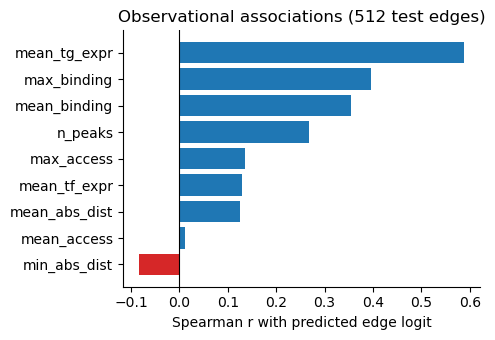

,spearman_r
min_abs_dist,-0.083032
mean_access,0.011809
mean_abs_dist,0.124087
mean_tf_expr,0.130120
max_access,0.134853
n_peaks,0.268128
mean_binding,0.354000
max_binding,0.396740
mean_tg_expr,0.587385


In [19]:
# Spearman correlation of each factor with the model's score, on the unperturbed edges.
factors = [
    "n_peaks", "min_abs_dist", "mean_abs_dist", "mean_access", "max_access",
    "mean_binding", "max_binding", "mean_tf_expr", "mean_tg_expr",
]

corr = (
    obs_df[factors + ["pred_logit"]]
    .corr(method="spearman")["pred_logit"]
    .drop("pred_logit")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ["tab:red" if v < 0 else "tab:blue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman r with predicted edge logit")
ax.set_title(f"Observational associations ({len(obs_df)} test edges)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

corr.to_frame("spearman_r")

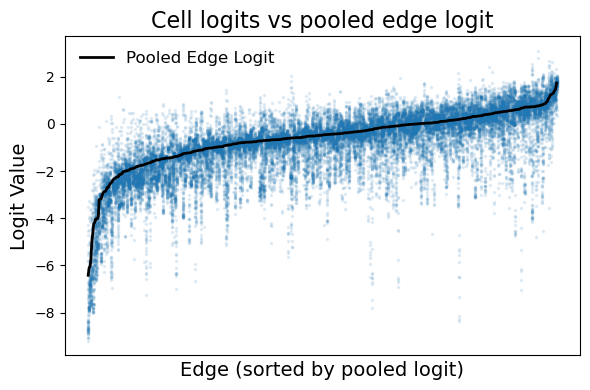

In [45]:
# The edge score is a log-sum-exp pool over C per-cell logits. How much do cells disagree?
fig= plt.figure(figsize=(6, 4))

order = np.argsort(obs_logits.numpy())
plt.plot(obs_cell_logits.numpy()[order], ".", color="tab:blue", alpha=0.10, ms=3)
plt.plot(obs_logits.numpy()[order], "-", color="black", lw=2, label="Pooled Edge Logit")
plt.xlabel("Edge (sorted by pooled logit)", fontsize=14)
plt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
plt.ylabel("Logit Value", fontsize=14)
plt.title("Cell logits vs pooled edge logit", fontsize=16)
plt.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()


## 5. Controlled sweeps

The pattern for every sweep below is the same:

1. Take one fixed batch of real edges.
2. Clone it, overwrite **one** input tensor, run the full forward.
3. Repeat over a grid of values and plot the response.

Everything else — TF identity, peak DNA sequences, the other four factors — is held at its
real value, so the curve is the model's response to that factor alone.

Sweep values are taken from the data's own quantiles wherever possible, so the grids stay
inside the range the model actually saw during training.

In [53]:
N_SWEEP = 2048   # every sweep step is a full forward on this many edges -- keep it small

sweep_batch = collect_edges(loader, n_pos=N_SWEEP // 2, n_neg=N_SWEEP // 2)
sweep_base_prob, sweep_base_logit, _ = predict_edges(sweep_batch)
print("baseline mean prob:", float(sweep_base_prob.mean()))


@torch.no_grad()
def sweep(base_batch, values, apply_fn, desc=""):
    """Run the model once per value, with apply_fn(batch_copy, value) applied in place."""
    rows = []
    for value in tqdm(values, desc=desc):
        perturbed = clone_batch(base_batch)
        apply_fn(perturbed, value)
        probs, logits, _ = predict_edges(perturbed)

        rows.append(pd.DataFrame({
            "value": value,
            "edge": np.arange(len(probs)),
            "tf": base_batch["tf_name"],
            "tg": base_batch["tg_name"],
            "label": base_batch["label"].numpy(),
            "prob": probs.numpy(),
            "logit": logits.numpy(),
        }))

    return pd.concat(rows, ignore_index=True)


def plot_sweep(df, xlabel, title, logx=False, y="prob"):
    fig, ax = plt.subplots(figsize=(5.5, 3.6))

    for label_value, color, name in [
        (1, "tab:blue", "true edges"),
        (0, "tab:red", "false edges"),
    ]:
        subset = df[df["label"] == label_value]

        if subset.empty:
            continue

        # Mean and standard deviation across edges at each sweep value
        stats = (
            subset
            .groupby("value")[y]
            .agg(["mean", "std"])
            .sort_index()
        )

        # std is NaN if only one observation exists at a value
        stats["std"] = stats["std"].fillna(0)

        # Mean
        ax.plot(
            stats.index,
            stats["mean"],
            color=color,
            lw=2.5,
            label=name,
        )

        # Mean ± 1 SD
        lower = np.clip(stats["mean"] - stats["std"], 0, 1)
        upper = np.clip(stats["mean"] + stats["std"], 0, 1)

        ax.fill_between(
            stats.index,
            lower,
            upper,
            color=color,
            alpha=0.2,
            linewidth=0,
        )

    if logx:
        ax.set_xscale("symlog", linthresh=1e3)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"predicted edge {y}")
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

collected 718 positives / 1024 negatives
baseline mean prob: 0.3756745755672455



### 5a. Number of peaks near the TG

Peaks are cached in order of increasing `|TSS_dist|`, so masking everything past column `k`
means "this TG only has its `k` closest peaks". Masked peaks are dropped from the attention
and their features are zeroed, which is what the model would see for a TG in a peak-poor
region.

The batch is filtered to edges that actually have `MAX_K` real peaks — otherwise the large-`k`
end of the sweep is a mix of edges that changed and edges that were already saturated.

sweeping k = 1..4 on 952 edges with >= 4 real peaks


n peaks:   0%|          | 0/4 [00:00<?, ?it/s]

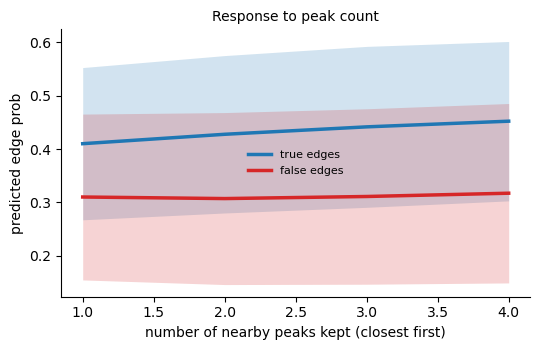

In [54]:
MAX_K = int(np.percentile(sweep_batch["peak_mask"].sum(1).numpy(), 50))
eligible = torch.nonzero(sweep_batch["peak_mask"].sum(1) >= MAX_K).ravel()
peak_batch = subset_batch(sweep_batch, eligible)
print(f"sweeping k = 1..{MAX_K} on {len(eligible)} edges with >= {MAX_K} real peaks")


def keep_k_closest_peaks(batch, k):
    """Mask out every peak except the k closest to the TSS."""
    P = batch["peak_mask"].shape[1]
    keep = torch.zeros(P, dtype=torch.bool)
    keep[:k] = True
    batch["peak_mask"] = batch["peak_mask"] & keep[None, :]


k_values = sorted(set(np.unique(np.linspace(1, MAX_K, 12).astype(int)).tolist()))
peak_count_df = sweep(peak_batch, k_values, keep_k_closest_peaks, desc="n peaks")

plot_sweep(peak_count_df, "number of nearby peaks kept (closest first)",
           "Response to peak count")


### 5b. Peak-to-TSS distance

Two versions, because they ask different questions:

* **Fixed distance** — every real peak is moved to the same `|TSS_dist| = d`. This isolates
  the distance features: `distance_scaled = clamp(d/250kb, 0, 1)` and
  `distance_weight = exp(-d/50kb)`. The grid deliberately runs past 250 kb to show where the
  clamp flattens the response.
* **Scaled distance** — real distances are multiplied by a factor, preserving each TG's peak
  geometry while pushing the whole neighbourhood in or out.

Note the cache only keeps peaks within 100 kb of the TSS, so distances above that are
extrapolation — informative about the model's function, not about data it was trained on.

fixed distance:   0%|          | 0/12 [00:00<?, ?it/s]

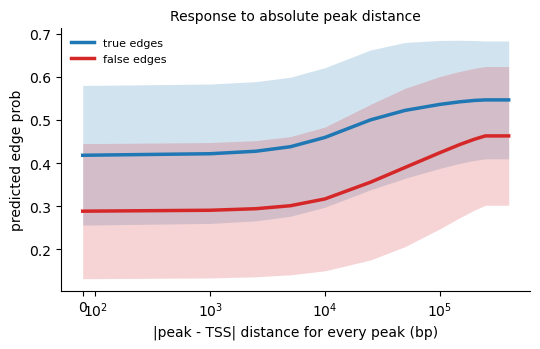

scaled distance:   0%|          | 0/8 [00:00<?, ?it/s]

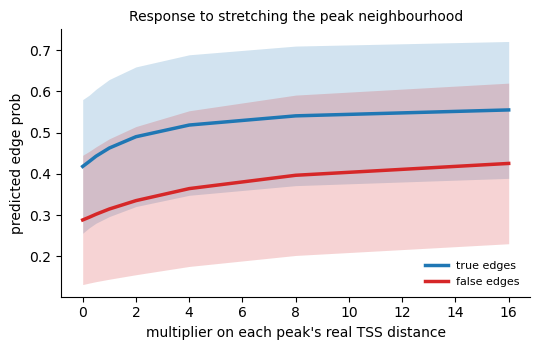

In [55]:
def set_all_distances(batch, d):
    """Move every real peak to |TSS_dist| = d, keeping its original sign."""
    sign = torch.sign(batch["peak_distance"])
    sign[sign == 0] = 1.0
    batch["peak_distance"] = torch.where(
        batch["peak_mask"], sign * float(d), batch["peak_distance"]
    )


def scale_distances(batch, factor):
    batch["peak_distance"] = torch.where(
        batch["peak_mask"], batch["peak_distance"] * float(factor), batch["peak_distance"]
    )


distance_values = [0, 1e3, 2.5e3, 5e3, 1e4, 2.5e4, 5e4, 1e5, 1.5e5, 2e5, 2.5e5, 4e5]
distance_df = sweep(sweep_batch, distance_values, set_all_distances, desc="fixed distance")
plot_sweep(distance_df, "|peak - TSS| distance for every peak (bp)",
           "Response to absolute peak distance", logx=True)

scale_values = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
distance_scale_df = sweep(sweep_batch, scale_values, scale_distances, desc="scaled distance")
plot_sweep(distance_scale_df, "multiplier on each peak's real TSS distance",
           "Response to stretching the peak neighbourhood")


### 5c. Peak accessibility

`peak_accessibility` is `[E, C, P]`, so setting a constant value replaces the ATAC signal
for every real peak in every sampled cell. The grid is drawn from the observed quantiles of
real-peak accessibility so the values stay on the model's training scale (which depends on
the pseudobulk normalization used for this sample).

observed accessibility quantiles: [0.     0.     0.0097 0.0483 0.1053 0.2057 0.6357]


accessibility:   0%|          | 0/10 [00:00<?, ?it/s]

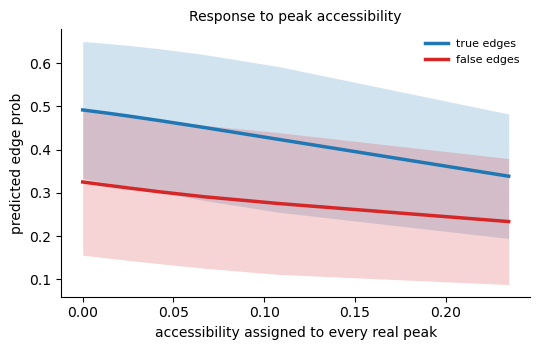

In [32]:
real_access = obs_batch["peak_accessibility"][obs_batch["peak_mask"][:, None, :].expand_as(obs_batch["peak_accessibility"])]
print("observed accessibility quantiles:",
      np.round(np.quantile(real_access.numpy(), [0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]), 4))


def set_accessibility(batch, a):
    """Set every real peak's accessibility to a, in every sampled cell."""
    full = torch.full_like(batch["peak_accessibility"], float(a))
    batch["peak_accessibility"] = torch.where(
        batch["peak_mask"][:, None, :], full, batch["peak_accessibility"]
    )


# np.unique: ATAC is zero-inflated, so the low quantiles collapse onto 0.0 and would
# otherwise put several sweep points on the same x value.
access_values = np.unique(np.quantile(real_access.numpy(), np.linspace(0.0, 0.995, 12))).tolist()
access_df = sweep(sweep_batch, access_values, set_accessibility, desc="accessibility")

plot_sweep(access_df, "accessibility assigned to every real peak",
           "Response to peak accessibility")


### 5d. TF and TG expression

Expression enters twice: as its own token concatenated into the classifier, and through
`tg_query = tg_query_proj(tf_expr_token + tg_expr_token)`, which is the query that attends
over the peaks. So expression can change the prediction both directly and by re-weighting
which peaks the model looks at.

Both sweeps set a constant value across all `C` sampled cells, which also removes the
cell-to-cell variation the log-sum-exp pooling normally sees.

TF expr quantiles: [0.    0.007 0.123 0.392 1.17  3.031]
TG expr quantiles: [0.00e+00 1.00e-03 6.60e-02 3.01e-01 9.51e-01 4.05e+00]


TF expression:   0%|          | 0/11 [00:00<?, ?it/s]

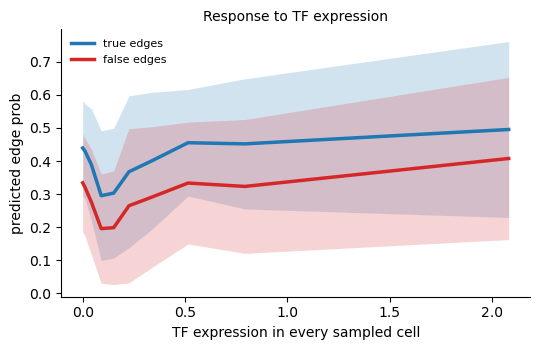

TG expression:   0%|          | 0/10 [00:00<?, ?it/s]

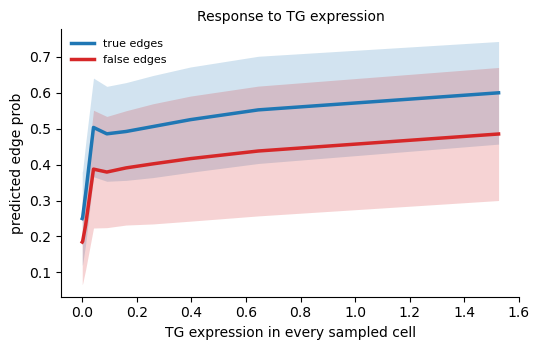

In [33]:
def set_tf_expression(batch, x):
    batch["tf_expression"] = torch.full_like(batch["tf_expression"], float(x))


def set_tg_expression(batch, x):
    batch["tg_expression"] = torch.full_like(batch["tg_expression"], float(x))


tf_expr_obs = obs_batch["tf_expression"].numpy().ravel()
tg_expr_obs = obs_batch["tg_expression"].numpy().ravel()
print("TF expr quantiles:", np.round(np.quantile(tf_expr_obs, [0, 0.25, 0.5, 0.75, 0.95, 1.0]), 3))
print("TG expr quantiles:", np.round(np.quantile(tg_expr_obs, [0, 0.25, 0.5, 0.75, 0.95, 1.0]), 3))

tf_expr_values = np.unique(np.quantile(tf_expr_obs, np.linspace(0.0, 0.99, 12))).tolist()
tg_expr_values = np.unique(np.quantile(tg_expr_obs, np.linspace(0.0, 0.99, 12))).tolist()

tf_expr_df = sweep(sweep_batch, tf_expr_values, set_tf_expression, desc="TF expression")
plot_sweep(tf_expr_df, "TF expression in every sampled cell", "Response to TF expression")

tg_expr_df = sweep(sweep_batch, tg_expr_values, set_tg_expression, desc="TG expression")
plot_sweep(tg_expr_df, "TG expression in every sampled cell", "Response to TG expression")


### 5e. TF x TG expression interaction

Because the two expression tokens are *summed* before the TG query projection, the model can
only see their joint value through that sum plus the two separate classifier inputs. A 2D
grid shows whether it has learned an interaction (a diagonal ridge) or just an additive
response (parallel contours).

TF x TG grid:   0%|          | 0/9 [00:00<?, ?it/s]

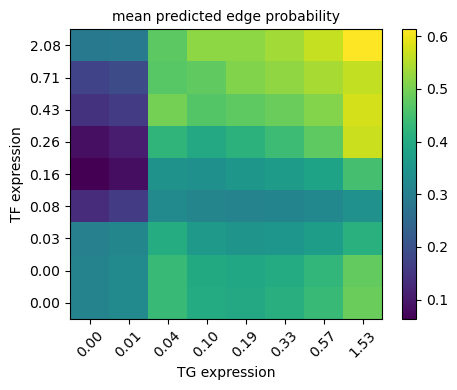

In [35]:
grid_n = 10
tf_grid = np.unique(np.quantile(tf_expr_obs, np.linspace(0.0, 0.99, grid_n)))
tg_grid = np.unique(np.quantile(tg_expr_obs, np.linspace(0.0, 0.99, grid_n)))

heat = np.zeros((len(tf_grid), len(tg_grid)))
for i, tf_value in enumerate(tqdm(tf_grid, desc="TF x TG grid")):
    for j, tg_value in enumerate(tg_grid):
        perturbed = clone_batch(sweep_batch)
        set_tf_expression(perturbed, tf_value)
        set_tg_expression(perturbed, tg_value)
        probs, _, _ = predict_edges(perturbed)
        heat[i, j] = float(probs.mean())

fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(heat, origin="lower", cmap="viridis", aspect="auto")
ax.set_xticks(range(len(tg_grid)), [f"{v:.2f}" for v in tg_grid], rotation=45)
ax.set_yticks(range(len(tf_grid)), [f"{v:.2f}" for v in tf_grid])
ax.set_xlabel("TG expression")
ax.set_ylabel("TF expression")
ax.set_title("mean predicted edge probability", fontsize=10)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### 5f. TF-DNA binding

Binding is the one peak feature that is *computed*, not looked up, so it cannot be swept by
editing an input tensor without also editing the DNA sequence. Two useful things instead:

* Look at how the binding scores are distributed across peaks, and how the edge score
  relates to them (already in `obs_df` as `mean_binding` / `max_binding`).
* Substitute the DNA: replace each peak's sequence with another peak's, which changes
  binding while leaving distance, accessibility, and expression untouched. That isolates the
  TF-DNA contribution to the TF-TG head.

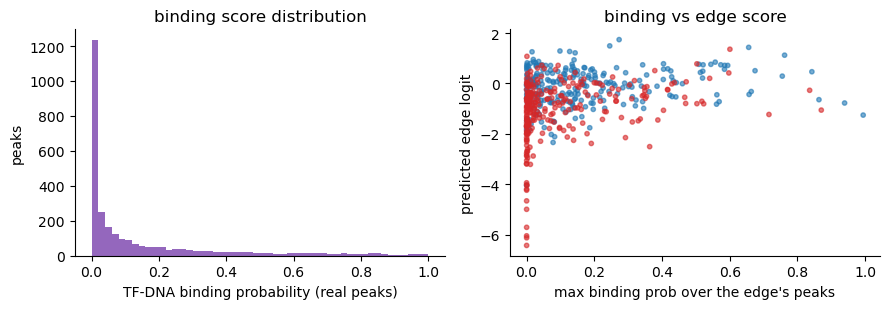

In [ ]:
# How much of the binding signal is TF-specific vs peak-specific?
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

real_binding = obs_binding[mask].numpy()
axes[0].hist(real_binding, bins=50, color="tab:purple")
axes[0].set_xlabel("TF-DNA binding probability (real peaks)")
axes[0].set_ylabel("peaks")
axes[0].set_title("binding score distribution")

axes[1].scatter(obs_df["mean_binding"], obs_df["pred_logit"],
                c=np.where(obs_df["label"] == 1, "tab:blue", "tab:red"), s=10, alpha=0.6)
axes[1].set_xlabel("mean binding prob over the edge's peaks")
axes[1].set_ylabel("predicted edge logit")
axes[1].set_title("binding vs edge score")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

DNA shuffle:   0%|          | 0/100 [00:00<?, ?it/s]

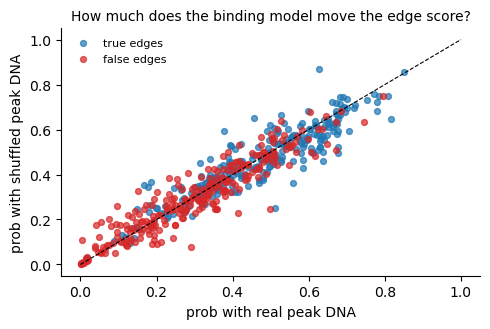

In [ ]:
# Shuffle which DNA sequence each peak carries, across edges in the batch. Distances,
# accessibility, and expression stay the same, only binding changes.
def shuffle_peak_dna(batch, seed):
    generator = torch.Generator().manual_seed(int(seed))
    E = batch["peak_sequences"].shape[0]
    perm = torch.randperm(E, generator=generator)
    batch["peak_sequences"] = batch["peak_sequences"][perm]


shuffle_df = sweep(sweep_batch, list(range(10)), shuffle_peak_dna, desc="DNA shuffle")

fig, ax = plt.subplots(figsize=(5, 3.4))
for label_value, color, name in [(1, "tab:blue", "true edges"), (0, "tab:red", "false edges")]:
    real = sweep_base_prob.numpy()[sweep_batch["label"].numpy() == label_value]
    shuffled = shuffle_df[shuffle_df["label"] == label_value].groupby("edge")["prob"].mean().values
    ax.scatter(real, shuffled, color=color, s=18, alpha=0.7, label=name)

lims = [0, 1]
ax.plot(lims, lims, color="black", lw=0.8, ls="--")
ax.set_xlabel("prob with real peak DNA")
ax.set_ylabel("prob with shuffled peak DNA")
ax.set_title("How much does the binding model move the edge score?", fontsize=10)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [56]:
obs_df

,tf,tg,label,pred_prob,pred_logit,n_peaks,min_abs_dist,mean_abs_dist,mean_access,max_access,mean_binding,max_binding,mean_tf_expr,mean_tg_expr,cell_logit_sd
0,NEUROD2,VPS37C,1.0,0.392110,-0.438449,3,59.0,7960.333496,0.040562,0.047142,0.011669,0.031690,0.000000,0.071471,0.260815
1,MAFK,SNX32,1.0,0.277282,-0.957984,1,2763.0,2763.000000,0.017841,0.017841,0.140461,0.140461,0.065212,0.058416,0.493055
2,HMGA2,DMRT1,1.0,0.661270,0.668957,16,3140.0,21327.625000,0.024058,0.063562,0.000583,0.002390,1.426902,0.009437,2.232558
3,TCF7L1,ATP9B,1.0,0.497396,-0.010417,21,193.0,7672.238281,0.037271,0.110536,0.019781,0.047879,1.042918,0.672537,0.432230
4,HMGA2,1700030N03RIK,1.0,0.479761,-0.080998,1,1232.0,1232.000000,0.025150,0.025150,0.000002,0.000002,1.282690,0.001997,2.049892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,MEIS1,TIMM21,0.0,0.495646,-0.017416,1,529.0,529.000000,0.010208,0.010208,0.429020,0.429020,0.379299,0.145528,0.450649
508,TCF7,STARD6,0.0,0.275576,-0.966516,5,2434.0,6681.600098,0.011047,0.018363,0.150843,0.234091,0.178228,0.018157,0.827407
509,TBP,ANKRD2,0.0,0.149179,-1.741057,1,2354.0,2354.000000,0.041062,0.041062,0.097388,0.097388,0.168851,0.001778,0.590304
510,E4F1,PDE6A,0.0,0.006796,-4.984672,7,363.0,7098.856934,0.037099,0.111766,0.000031,0.000062,0.131553,0.015190,0.925162
